In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [2]:
# Load your trained model
model = tf.keras.models.load_model("InceptionV3_Model.h5")

In [3]:
from tensorflow.keras.models import load_model

model = load_model("InceptionV3_Model.h5", compile=False)  # Load without compiling
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [4]:
img_path = r"E:\Junaed_Jibon\Model_Training\Test_Images\image_03969.jpg"  # Ensure this file exists
img = cv2.imread(img_path)

if img is None:
    print("Error: Image not found! Check the file path.")
else:
    img = cv2.resize(img, (299, 299))  # Resize to 299x299 for InceptionV3
    img = img / 255.0  # Normalize the image
    img = np.expand_dims(img, axis=0)


In [5]:
def grad_cam(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0])  # Get the predicted class index
        loss = predictions[:, class_idx]  # Loss for the predicted class

    grads = tape.gradient(loss, conv_outputs)  # Compute gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # Global average pooling
    conv_outputs = conv_outputs.numpy()[0]
    pooled_grads = pooled_grads.numpy()

    # Multiply each channel by the corresponding gradient importance
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)  # Average over all feature maps
    heatmap = np.maximum(heatmap, 0)  # ReLU (no negative values)
    heatmap /= np.max(heatmap)  # Normalize

    return heatmap, class_idx


In [6]:
layer_name = "mixed10"  # Change this based on your model (e.g., 'block5_conv3' for VGG19)
heatmap, predicted_class = grad_cam(model, img, layer_name)


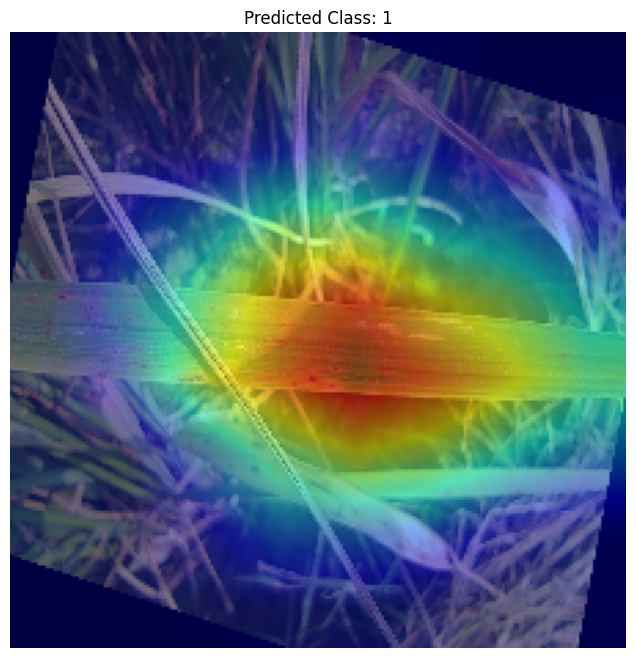

In [7]:
def overlay_heatmap(img_path, heatmap, alpha=0.5):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))  # Resize if needed
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))  # Resize to match image

    heatmap = np.uint8(255 * heatmap)  # Convert heatmap to 0-255 range
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Apply color mapping

    # Overlay the heatmap on the original image
    superimposed_img = cv2.addWeighted(img, alpha, heatmap, 1 - alpha, 0)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Predicted Class: {predicted_class}")
    plt.show()

# Call the function to display the result
overlay_heatmap(img_path, heatmap)
